In [1]:
import os
import torch
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
from datasets import load_dataset


device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "openai/whisper-large-v3"

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
)
model.to(device)

processor = AutoProcessor.from_pretrained(model_id)

/media/nit/DATADRIVE1/AJAY/MLproject/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-30 23:17:06.619933: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 23:17:06.668087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 23:17:08.232945: I tensorflow/co

In [3]:
DATASETS = {
    'train': [
        {
            'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_train.csv',
            'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/train_split'
        },
        {
            'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_train.csv',
            'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/train_split'
        }
    ],

    'val': [
        {
            'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_val.csv',
            'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/val_split'
        },
        {
            'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_val.csv',
            'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/val_split'
        }
    ],

    'test': [
        {
            'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_test.csv',
            'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/test_split'
        },
        {
            'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_test.csv',
            'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/test_split'
        }
    ]
}
SAVE_DIR = "/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD"

In [4]:
def extract_embedding(audio):
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_features = inputs.input_features.to(device).to(torch_dtype)
    
    with torch.no_grad():
        encoder_outputs = model.get_encoder()(input_features)
        
    hidden_states = encoder_outputs.last_hidden_state
    
    emb_mean = hidden_states.mean(dim=1).squeeze().cpu().numpy()
    emb_std = hidden_states.std(dim=1).squeeze().cpu().numpy()
    emb_max = hidden_states.max(dim=1)[0].squeeze().cpu().numpy()
    emb = np.hstack((emb_mean, emb_std, emb_max))
    
    return emb

In [5]:
def load_split(dataset_list):
    X = []
    y = []
    
    
    missing_files = 0
    too_short = 0
    processing_errors = 0

    for dataset in dataset_list:
        csv_path = dataset['csv']
        audio_path = dataset['audio']
        df = pd.read_csv(csv_path)

        for _, row in tqdm(df.iterrows(), total=len(df)):
            file = os.path.join(audio_path, row['segment_id'])

            if not os.path.exists(file):
                missing_files += 1
                continue

            try:
                audio, sr = librosa.load(file, sr=16000)
                start = int(row['start_time'] * sr)
                end = int(row['end_time'] * sr)
                audio = audio[start:end]
                if len(audio) < 300:
                    too_short += 1
                    continue
                emb = extract_embedding(audio)
                X.append(emb)
                y.append(row['label'])

            except Exception as e:
                processing_errors += 1
                continue

    print(f"\n--- Data Loading Report ---")
    print(f"Successfully loaded: {len(X)}")
    print(f"Dropped (File missing): {missing_files}")
    print(f"Dropped (Too short < 300 samples): {too_short}")
    print(f"Dropped (Processing Error): {processing_errors}")
    print(f"---------------------------\n")

    return np.array(X), np.array(y)

In [6]:
print("Loading Train Data")
X_train, y_train = load_split(DATASETS['train'])

print("Loading Val Data")
X_val, y_val = load_split(DATASETS['val'])

print("Loading Test Data")
X_test, y_test = load_split(DATASETS['test'])

Loading Train Data


100%|█████████████████████████████████████| 12641/12641 [16:15<00:00, 12.96it/s]



--- Data Loading Report ---
Successfully loaded: 35272
Dropped (File missing): 0
Dropped (Too short < 300 samples): 0
Dropped (Processing Error): 16
---------------------------

Loading Val Data


100%|███████████████████████████████████████| 1745/1745 [02:16<00:00, 12.77it/s]



--- Data Loading Report ---
Successfully loaded: 5108
Dropped (File missing): 0
Dropped (Too short < 300 samples): 0
Dropped (Processing Error): 1
---------------------------

Loading Test Data


100%|███████████████████████████████████████| 3433/3433 [04:27<00:00, 12.82it/s]


--- Data Loading Report ---
Successfully loaded: 9971
Dropped (File missing): 0
Dropped (Too short < 300 samples): 0
Dropped (Processing Error): 8
---------------------------



In [7]:
np.save("/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/X_train.npy", X_train)
np.save("/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/y_train.npy", y_train)

np.save("/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/X_val.npy", X_val)
np.save("/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/y_val.npy", y_val)

np.save("/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/X_test.npy", X_test)
np.save("/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/y_test.npy", y_test)

In [8]:
label_map = {
    "eng": 0,
    "hin": 1
}


orig_train_size = len(y_train)
orig_val_size = len(y_val)
orig_test_size = len(y_test)


y_train = np.array([label_map.get(i, -1) for i in y_train])
y_val = np.array([label_map.get(i, -1) for i in y_val])
y_test = np.array([label_map.get(i, -1) for i in y_test])


mask_train = y_train != -1
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_val = y_val != -1
X_val = X_val[mask_val]
y_val = y_val[mask_val]

mask_test = y_test != -1
X_test = X_test[mask_test]
y_test = y_test[mask_test]


print("--- Invalid Labels Removed ---")
print(f"Train: {orig_train_size - len(y_train)} samples removed (out of {orig_train_size})")
print(f"Val:   {orig_val_size - len(y_val)} samples removed (out of {orig_val_size})")
print(f"Test:  {orig_test_size - len(y_test)} samples removed (out of {orig_test_size})")
print("------------------------------")

--- Invalid Labels Removed ---
Train: 0 samples removed (out of 35272)
Val:   0 samples removed (out of 5108)
Test:  0 samples removed (out of 9971)
------------------------------


In [9]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [11]:
svm = SVC(kernel='rbf', C=10, probability=True)

svm.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
import joblib
import os
joblib.dump(svm,'/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/svm_model_saved.pkl')

['/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/svm_model_saved.pkl']

In [13]:
pred = svm.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Test Accuracy:", acc)

Test Accuracy: 0.9000100290843446


In [14]:
pred1 = svm.predict(X_val)

acc1 = accuracy_score(y_val, pred1)

print("Validation Accuracy:", acc1)

Validation Accuracy: 0.8997650743931088


<Figure size 800x600 with 0 Axes>

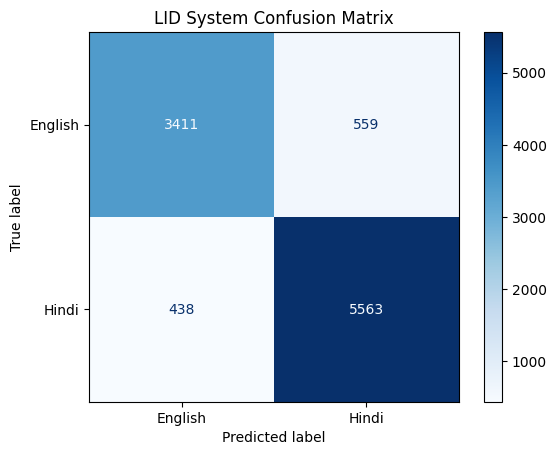


Classification Report:
              precision    recall  f1-score   support

         eng       0.89      0.86      0.87      3970
         hin       0.91      0.93      0.92      6001

    accuracy                           0.90      9971
   macro avg       0.90      0.89      0.90      9971
weighted avg       0.90      0.90      0.90      9971



In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['English', 'Hindi']

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

print('\nClassification Report:')
target_names = ['eng', 'hin'] 
print(classification_report(y_test, pred, target_names=target_names))

In [16]:
import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm

rev_label_map = {0: "eng", 1: "hin"}

def append_predictions_to_csv(csv_path, audio_path, output_csv_path, model, scaler):
    df = pd.read_csv(csv_path)
    predictions = []
    
    print(f"Processing {csv_path}...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        file = os.path.join(audio_path, row['segment_id'])
        
        if not os.path.exists(file):
            predictions.append("Dropped (Missing)")
            continue
            
        try:
            audio, sr = librosa.load(file, sr=16000)
            start = int(row['start_time'] * sr)
            end = int(row['end_time'] * sr)
            audio_segment = audio[start:end]
            
            if len(audio_segment) < 300:
                predictions.append("Dropped (<300 frames)")
                continue    
            
            emb = extract_embedding(audio_segment) 
            emb_scaled = scaler.transform(emb.reshape(1, -1))
            pred_idx = model.predict(emb_scaled)[0]
            
            predictions.append(rev_label_map[pred_idx])
            
        except Exception:
            predictions.append("Dropped (Error)")
            
    df['predicted_label'] = predictions
    
    df.to_csv(output_csv_path, index=False)
    print(f"Done! Saved to: {output_csv_path}\n")

append_predictions_to_csv(
    csv_path='/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_test.csv',
    audio_path='/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/test_split',
    output_csv_path='/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/adult_test_predictions_svm.csv',
    model=svm, 
    scaler=scaler
)

append_predictions_to_csv(
    csv_path='/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_test.csv',
    audio_path='/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/test_split',
    output_csv_path='/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/children_test_predictions_svm.csv',
    model=svm, 
    scaler=scaler
)

Processing /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_test.csv...


100%|███████████████████████████████████████| 6546/6546 [10:40<00:00, 10.23it/s]


Done! Saved to: /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/adult_test_predictions_svm.csv

Processing /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_test.csv...


100%|███████████████████████████████████████| 3433/3433 [05:38<00:00, 10.16it/s]


Done! Saved to: /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/children_test_predictions_svm.csv

